> # SECTION -3

<h4>

**Create quantum circuits**

--- 
- Construct basic quantum circuits
- Construct dynamic circuits
- Construct parameterized circuits
- **Transpile and optimize circuits**
---

</h4>

In [1]:
from platform import python_version
import qiskit
print("Python version ", python_version())
print(f"Qiskit version: {qiskit.__version__}")

Python version  3.13.5
Qiskit version: 2.5.0


> ## Transpile and optimize circuits

REFERENCE : 

https://quantum.cloud.ibm.com/docs/en/guides/transpile

https://quantum.cloud.ibm.com/docs/en/guides/defaults-and-configuration-options

https://quantum.cloud.ibm.com/docs/en/api/qiskit/transpiler

**TRANSPILE:** process of rewriting a given input circuit to match the topology of a specific quantum device, and optimize the circuit instructions for execution on noisy quantum computers

---
#### BEFORE transpilation

---

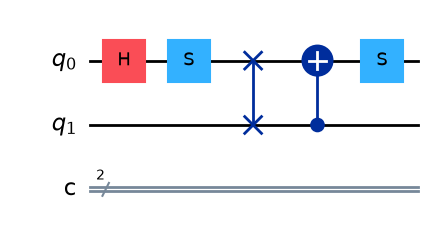

In [2]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2,2)
qc.h(0)
qc.s(0)
qc.swap(0,1)
qc.cx(1,0)
qc.s(0)

qc.draw("mpl")

---
#### AFTER transpilation

---

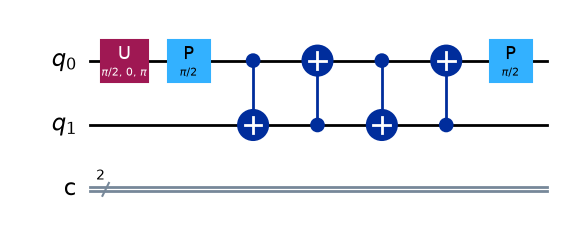

In [3]:
qc.decompose().draw("mpl")

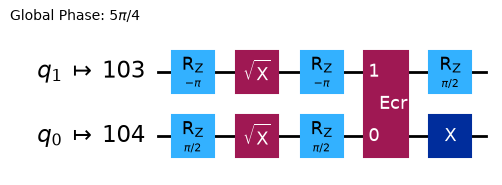

In [4]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
# Specify the QPU to target
backend = FakeSherbrooke()

# Transpile the circuit
pass_manager = generate_preset_pass_manager(backend=backend)
transpiled_circ = pass_manager.run(qc)

# View the transpiled circuit
transpiled_circ.draw(output="mpl", idle_wires=False)

---
## Stages of prebuilt transpilation pipeline in the Qiskit SDK. There are six stages:

---
<h4>

1. init

    translates multi-qubit gates into single- and two-qubit gates

2. layout

    mapping the virtual qubits in your circuit to the QPU's physical qubits

3. routing
    original circuit to make it compatible with the QPU's connectivity (coupling map)

4. translation

    translates the gates in the circuit to the QPU's basis set of instructions

5. optimization

    more efficient decompositions of the quantum circuit until a condition is met
    
6. scheduling

</h4>

> ## Optimize circuits

REFERENCE : https://quantum.cloud.ibm.com/docs/en/guides/set-optimization

<h4>

Integer in the range (0 - 3). 

Higher levels generate more optimized circuits, at the expense of longer transpilation time

- 0 : no optimization
- 1 : Light optimization
- 2 : Medium optimization
- 3 : High Optimization

</h4>

---
**using optimization level to 1:**

---

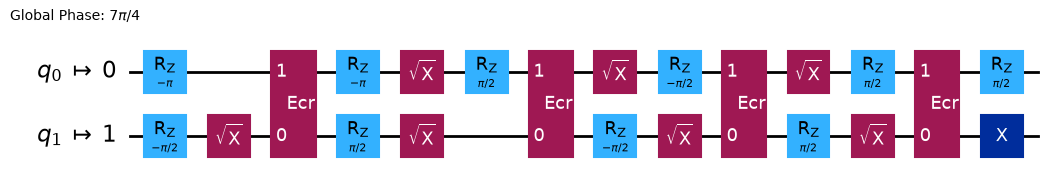

In [5]:
# optimization_level=1


from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
# Specify the QPU to target
backend = FakeSherbrooke()

# Transpile the circuit
pass_manager = generate_preset_pass_manager(backend=backend,optimization_level=1)
transpiled_circ = pass_manager.run(qc)

# View the transpiled circuit
transpiled_circ.draw(output="mpl", idle_wires=False)

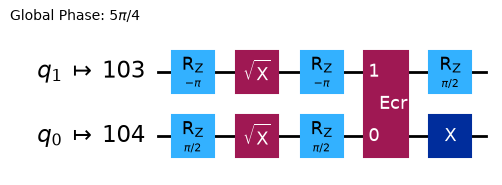

In [6]:
# optimization_level=2



from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
# Specify the QPU to target
backend = FakeSherbrooke()

# Transpile the circuit
pass_manager = generate_preset_pass_manager(backend=backend,optimization_level=2)
transpiled_circ = pass_manager.run(qc)

# View the transpiled circuit
transpiled_circ.draw(output="mpl", idle_wires=False)

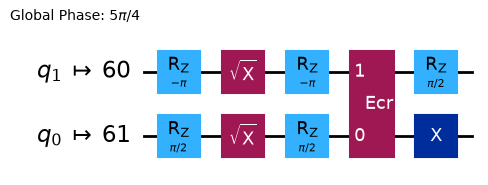

In [7]:
# optimization_level=3



from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
# Specify the QPU to target
backend = FakeSherbrooke()

# Transpile the circuit
pass_manager = generate_preset_pass_manager(backend=backend,optimization_level=3)
transpiled_circ = pass_manager.run(qc)

# View the transpiled circuit
transpiled_circ.draw(output="mpl", idle_wires=False)